# 03 · Modelo base (sin FAIR) — Taller B4-T1

**Objetivo.** Entrenar un **MLP estándar** sobre el contrato de datos `(X, y, s)` del preprocesado (`02_preprocesado.ipynb`), **SIN penalización de equidad**: $\lambda = 0$, sin *FAIR loss*, sin capa custom. Es deliberadamente la versión "ingenua" del clasificador de impago.

El género `s` (`CODE_GENDER`) **nunca es input** del modelo (las 13 features de `X` no lo contienen, D-P.1–D-P.7); `s` se reserva **solo para la auditoría de equidad** (group gap M−F y tasas por grupo).

Este notebook **fija la línea de partida**: el **AUC-ROC** y **accuracy** de referencia (D-2.4) y el **group gap base** que las Tareas 2/3/4 intentarán mejorar o mantener. La línea base de equidad del EDA es **+3,14 pp** (M 10,14 % vs F 7,00 % de impago real). En el mapa de entregables es la **"mitad base"** de la tabla **E5** (*base vs mejor FAIR*, que ensambla el notebook 05) y aporta su propia **curva de loss base (E4)**.

## Decisiones a tomar antes de empezar

> Fichas de `docs/DECISIONES.md` para esta tarea. **Estado real** copiado tal cual.
> A diferencia de las Tareas 1-4 (en Propuesta/Abierta), las fichas **propias** del modelo
> base (**D-MB.1–D-MB.5**) ya están **Confirmadas** por el grupo (2026-06-20). Las decisiones
> que el base solo **consume / condiciona** (D-2.x, D-3.2, D-4.1) conservan su estado real
> (Propuesta) y se validan en sus respectivas tareas.

**Fichas propias del modelo base** (sección *"Modelo base (NB 03)"* de `DECISIONES.md`):

| Decisión | Contenido | Estado |
|---|---|---|
| **D-MB.1** · Arquitectura del MLP base | `Dense(64,relu) → Dropout(0.3) → Dense(32,relu) → Dropout(0.3) → Dense(1,sigmoid)`, sin capa custom, $\lambda=0$ | **Confirmada** |
| **D-MB.2** · Compilación | `binary_crossentropy` + `Adam` + métrica `AUC` (alineada con D-2.4) | **Confirmada** |
| **D-MB.3** · Desbalance | `class_weight` "balanced" desde train (sin resampling) | **Confirmada** |
| **D-MB.4** · Entrenamiento / parada / umbral | **150 épocas fijas** (sin EarlyStopping) + `ReduceLROnPlateau(val_auc)` + `ModelCheckpoint` de mejores pesos (`val_auc`); umbral 0,5 provisional (coste → D-4.4) | **Confirmada** |
| **D-MB.5** · Auditoría de equidad | group gap M−F + tasas por grupo (métrica de D-2.3); el género nunca es input | **Confirmada** |

**Decisiones de otras tareas que el base consume / condiciona** (estado real, se validan fuera del base):

| Decisión | Rol en el modelo base | Estado |
|---|---|---|
| **D-P.1 … D-P.7** · Contrato de datos `(X, y, s)` (consumidas tal cual; `X` = 13 features sin género; no se reimputa ni reescala) | Define los inputs/salida del MLP base | **Confirmada** (×7) |
| **D-2.4** · Métrica de precisión = **AUC-ROC** | El base la **fija como valor de partida** | Propuesta |
| **D-2.3** · Métrica de equidad = **group gap M−F + tasas** | El base **reporta su gap** (baseline EDA +3,14 pp) | Propuesta |
| **D-3.2 / D-4.1** · El MLP base incluye **Dropout** | Palanca para que el tuner (06) lo busque y la Tarea 4 (07) lo reutilice en **MC-Dropout** (cruce D-3.2↔D-4.1) | Propuesta |

> **Aviso.** Las **D-MB.\*** (fichas propias del base) están **Confirmadas** (Grupo / 2026-06-20).
> El base **asume cerradas las D-P.\*** (contrato de datos del preprocesado) y solo **consume / condiciona**
> las **D-2.\* / D-3.2 / D-4.1** (Propuesta), que se validan en sus tareas. Se **monta el Dropout aunque
> $\lambda = 0$** para **no romper la cadena 06→07** (el tuner busca su `rate` y la Tarea 4 lo reutiliza
> para MC-Dropout).

In [1]:
# === Setup comun (notebooks de modelado 03-07) ===
import os
os.environ["KERAS_BACKEND"] = "tensorflow"   # backend unico para todo el grupo

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibilidad
RNG = 42
np.random.seed(RNG)
import random; random.seed(RNG)
try:
    import keras
    keras.utils.set_random_seed(RNG)
except Exception:
    pass

# Estilo heredado del EDA / preprocesado
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
COLOR_PAGA   = "#2c7fb8"   # TARGET=0  (paga)
COLOR_IMPAGA = "#d7301f"   # TARGET=1  (impaga)
COLOR_ACENTO = "#41ab5d"   # neutro

# Rutas estandar
PROC_DIR = Path("../data/processed")
FIG_DIR  = Path("../results/figures"); FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR  = Path("../results/tables");  TAB_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
import json
from pathlib import Path
import pandas as pd

# --- Rutas y metadatos (fuente de verdad: metadata.json del preprocesado) ---
PROC_DIR   = Path("../data/processed")                       # relativo a notebooks/
META       = json.loads((PROC_DIR / "metadata.json").read_text(encoding="utf-8"))
FEATURES_X = META["columns"]["features_X"]   # 13 features, en orden
SENSIBLE   = META["columns"]["sensible"]     # "CODE_GENDER"  (s)
TARGET     = META["columns"]["target"]       # "TARGET"       (y)

def cargar_split(nombre):
    """Devuelve (X, y, s) para 'train' | 'val' | 'test'.
    X = DataFrame solo con las 13 features (SIN genero).
    y = Series TARGET (1=impaga, 0=paga).  s = Series CODE_GENDER (M=1/F=0).
    """
    df = pd.read_parquet(PROC_DIR / f"{nombre}.parquet")
    X = df[FEATURES_X]          # input del modelo: el genero NUNCA entra aqui
    y = df[TARGET]
    s = df[SENSIBLE]
    assert SENSIBLE not in X.columns, "FUGA: el genero esta dentro de X"
    return X, y, s

# Materializar los tres cortes
X_train, y_train, s_train = cargar_split("train")
X_val,   y_val,   s_val   = cargar_split("val")
X_test,  y_test,  s_test  = cargar_split("test")

# Resumen de control
print(f"{'split':<7}{'X (filas, cols)':>20}{'y':>12}{'s':>12}{'tasa_impago':>14}")
for n, (X, y, s) in {"train": (X_train, y_train, s_train),
                     "val":   (X_val,   y_val,   s_val),
                     "test":  (X_test,  y_test,  s_test)}.items():
    print(f"{n:<7}{str(tuple(X.shape)):>20}{str(tuple(y.shape)):>12}"
          f"{str(tuple(s.shape)):>12}{y.mean():>14.4%}")

split       X (filas, cols)           y           s   tasa_impago
train          (215254, 13)   (215254,)   (215254,)       8.0728%
val             (46126, 13)    (46126,)    (46126,)       8.0735%
test            (46127, 13)    (46127,)    (46127,)       8.0734%


## Definición del MLP base

Aquí se definirá el **MLP estándar de referencia**: `Sequential` de capas `Dense` con activación intermedia, **`Dropout`** (palanca D-3.2/D-4.1, montada aunque $\lambda = 0$) y salida `sigmoide`; **sin** capa custom ni *FAIR loss*.

In [3]:
# === Definicion del MLP base (sin FAIR, lambda = 0) ===
# Arquitectura de referencia acordada por el grupo (2026-06-20):
#   Input(13) -> Dense(64, relu) -> Dropout(0.3) -> Dense(32, relu) -> Dropout(0.3) -> Dense(1, sigmoid)
# El Dropout(0.3) es la palanca D-3.2/D-4.1: se monta AUNQUE lambda = 0 para
# no romper la cadena 03 -> 06 (el tuner buscara su rate) -> 07 (MC-Dropout).
# NO hay capa custom ni FAIR loss aqui: este es deliberadamente el modelo "ingenuo".

N_FEATURES = X_train.shape[1]   # 13 features (sin genero)
DROPOUT_RATE = 0.3              # FIJO en el base (palanca D-3.2/D-4.1)

model = keras.Sequential(
    [
        keras.Input(shape=(N_FEATURES,), name="entrada_13_features"),
        keras.layers.Dense(64, activation="relu", name="densa_1"),
        keras.layers.Dropout(DROPOUT_RATE, name="dropout_1"),   # D-3.2 / D-4.1
        keras.layers.Dense(32, activation="relu", name="densa_2"),
        keras.layers.Dropout(DROPOUT_RATE, name="dropout_2"),   # D-3.2 / D-4.1
        keras.layers.Dense(1, activation="sigmoid", name="salida_impago"),
    ],
    name="mlp_base_sin_fair",
)

# Compilacion: BCE + Adam, metrica principal AUC (D-2.4), accuracy auxiliar.
model.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(),
    metrics=[keras.metrics.AUC(name="auc"), "accuracy"],
)

model.summary()

Model: "mlp_base_sin_fair"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densa_1 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densa_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida_impago (Dense)           │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento + curva de loss (E4)

Se entrena el MLP base con **BCE + Adam**, validando en `val`, durante **150 épocas fijas** (sin `EarlyStopping`: el entrenamiento corre las 150 enteras). El desbalance (~8 % de impago) se compensa con **`class_weight` balanceado calculado solo desde `train`** — sin tocar la salida ni el umbral. Dos *callbacks* gobiernan la convergencia (D-MB.4):

- **`ReduceLROnPlateau(monitor="val_auc", factor=0.5, patience=8, min_lr=1e-6)`** — baja el *learning rate* a la mitad cuando el `val_auc` se estanca, afinando la última parte del descenso (D-2.4 fija el AUC como criterio).
- **`ModelCheckpoint(monitor="val_auc", save_best_only=True)`** — guarda los pesos del **mejor `val_auc`**. No corta el entrenamiento; al terminar se **recargan esos pesos** (`model.load_weights`), de modo que nos quedamos con la **mejor** versión y no con la de la época 150 por si el tramo final sobreajustara.

La **curva de loss base (entregable E4)** muestra train vs validación por época, marca la **mejor época** (pesos restaurados) y señala con líneas tenues los **escalones de reducción de LR**: se guarda en `FIG_DIR/03_base__curva_loss.png`. Es la convergencia de referencia que el tuner (06) tratará de mejorar.

class_weight (balanced desde train): {0: 0.5439, 1: 6.1936}

Epoch 1/150


421/421 - 5s - 12ms/step - accuracy: 0.6475 - auc: 0.7059 - loss: 0.6276 - val_accuracy: 0.6831 - val_auc: 0.7322 - val_loss: 0.6012 - learning_rate: 0.0010


Epoch 2/150


421/421 - 2s - 4ms/step - accuracy: 0.6726 - auc: 0.7241 - loss: 0.6148 - val_accuracy: 0.6932 - val_auc: 0.7347 - val_loss: 0.5926 - learning_rate: 0.0010


...

421/421 - 3s - 6ms/step - accuracy: 0.6895 - auc: 0.7430 - loss: 0.5987 - val_accuracy: 0.6899 - val_auc: 0.7402 - val_loss: 0.5985 - learning_rate: 1.0000e-06


Epoch 150/150


421/421 - 3s - 6ms/step - accuracy: 0.6898 - auc: 0.7422 - loss: 0.5995 - val_accuracy: 0.6899 - val_auc: 0.7402 - val_loss: 0.5985 - learning_rate: 1.0000e-06



Epocas ejecutadas: 150 (fijas, sin EarlyStopping)
Mejor val_auc: 0.7403 (epoca 70) -> pesos restaurados desde checkpoint
Reducciones de LR (ReduceLROnPlateau) en epocas: [33, 48, 56, 64, 72, 80, 88, 96, 104, 112]


Figura E4 guardada en: ..\results\figures\03_base__curva_loss.png


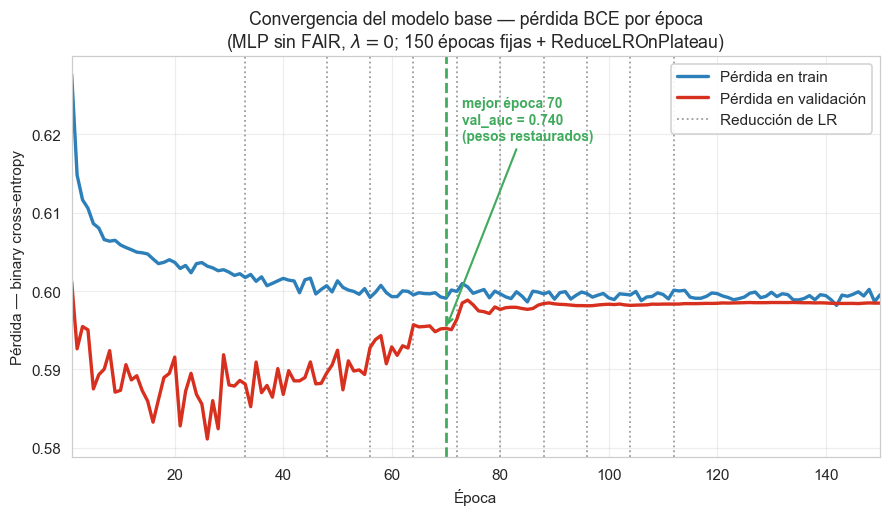

In [4]:
# === Entrenamiento + curva de loss base (entregable E4) ===
import tempfile, os
from sklearn.utils.class_weight import compute_class_weight

# --- Desbalance: class_weight balanceado calculado SOLO desde train (~8.07% impago) ---
cw = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train.to_numpy())
class_weight = {0: float(cw[0]), 1: float(cw[1])}
print(f"class_weight (balanced desde train): {{0: {class_weight[0]:.4f}, 1: {class_weight[1]:.4f}}}")

# --- Conversion a numpy float32 en el punto de uso ---
Xtr = X_train.to_numpy("float32"); ytr = y_train.to_numpy("float32")
Xvl = X_val.to_numpy("float32");   yvl = y_val.to_numpy("float32")

# --- Estrategia de entrenamiento (D-MB.4): 150 epocas FIJAS, sin EarlyStopping ---
# El fit corre las 150 epocas completas. Dos callbacks:
#   1) ReduceLROnPlateau: baja el LR (x0.5) cuando val_auc se estanca -> afina la convergencia.
#   2) ModelCheckpoint(save_best_only): guarda los pesos del mejor val_auc. NO corta el
#      entrenamiento; solo permite recuperar la MEJOR version al final (no la de la epoca 150)
#      por si hubiera sobreajuste en el tramo final.
EPOCHS = 150
ckpt_path = os.path.join(tempfile.gettempdir(), "03_base_best.weights.h5")

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_auc", mode="max", factor=0.5, patience=8, min_lr=1e-6, verbose=1,
)
checkpoint = keras.callbacks.ModelCheckpoint(
    ckpt_path, monitor="val_auc", mode="max",
    save_best_only=True, save_weights_only=True, verbose=0,
)

history = model.fit(
    Xtr, ytr,
    validation_data=(Xvl, yvl),
    class_weight=class_weight,
    epochs=EPOCHS,
    batch_size=512,
    callbacks=[reduce_lr, checkpoint],
    verbose=2,
)

# --- Recuperar la MEJOR version (mejor val_auc), no la de la ultima epoca ---
model.load_weights(ckpt_path)

# --- Resumen del entrenamiento ---
val_auc_hist = history.history["val_auc"]
n_epocas = len(history.history["loss"])
best_epoch = int(np.argmax(val_auc_hist))          # indice 0-based
best_val_auc = float(val_auc_hist[best_epoch])
print(f"\nEpocas ejecutadas: {n_epocas} (fijas, sin EarlyStopping)")
print(f"Mejor val_auc: {best_val_auc:.4f} (epoca {best_epoch + 1}) -> pesos restaurados desde checkpoint")

# --- Epocas donde ReduceLROnPlateau bajo el learning rate (para anotar en la curva) ---
lr_hist = history.history.get("learning_rate", history.history.get("lr"))
epocas_lr_drop = []
if lr_hist is not None:
    for i in range(1, len(lr_hist)):
        if lr_hist[i] < lr_hist[i - 1] - 1e-12:
            epocas_lr_drop.append(i + 1)             # epoca 1-based donde el LR ya bajo
    print(f"Reducciones de LR (ReduceLROnPlateau) en epocas: {epocas_lr_drop or 'ninguna'}")

# --- Curva de loss (E4): train vs val por epoca ---
loss_tr  = history.history["loss"]
loss_val = history.history["val_loss"]
epocas   = np.arange(1, n_epocas + 1)

fig, ax = plt.subplots(figsize=(8.2, 4.8))
ax.plot(epocas, loss_tr,  color=COLOR_PAGA,   lw=2.2, label="Pérdida en train")
ax.plot(epocas, loss_val, color=COLOR_IMPAGA, lw=2.2, label="Pérdida en validación")

y_top = max(max(loss_tr), max(loss_val))
y_bot = min(min(loss_tr), min(loss_val))

# Escalones de reduccion de LR (lineas grises tenues)
for k, e in enumerate(epocas_lr_drop):
    ax.axvline(e, color="#9e9e9e", ls=":", lw=1.2, zorder=1,
               label="Reducción de LR" if k == 0 else None)

# Linea vertical + anotacion de la mejor epoca (pesos restaurados por ModelCheckpoint)
ax.axvline(best_epoch + 1, color=COLOR_ACENTO, ls="--", lw=1.8, zorder=2)
ax.annotate(
    f"mejor época {best_epoch + 1}\nval_auc = {best_val_auc:.3f}\n(pesos restaurados)",
    xy=(best_epoch + 1, loss_val[best_epoch]),
    xytext=(best_epoch + 1 + 3, y_top - 0.06 * (y_top - y_bot)),
    color=COLOR_ACENTO, fontsize=9, fontweight="bold", ha="left", va="top",
    arrowprops=dict(arrowstyle="->", color=COLOR_ACENTO, lw=1.4),
)

ax.set_title("Convergencia del modelo base — pérdida BCE por época\n"
             "(MLP sin FAIR, $\\lambda=0$; 150 épocas fijas + ReduceLROnPlateau)",
             fontsize=11.5)
ax.set_xlabel("Época")
ax.set_ylabel("Pérdida — binary cross-entropy")
ax.set_xlim(1, n_epocas)
ax.grid(True, alpha=0.35)
ax.legend(loc="upper right", frameon=True, framealpha=0.9)
fig.tight_layout()

# Entregable E4
ruta_e4 = FIG_DIR / "03_base__curva_loss.png"
fig.savefig(ruta_e4, bbox_inches="tight", dpi=150)
print(f"Figura E4 guardada en: {ruta_e4}")
plt.show()

## Evaluación en test

Se calculan en **test** (corte nunca visto) las dos familias de métricas que fijan la línea base:

- **Precisión (D-2.4):** **AUC-ROC** como métrica principal y *accuracy* (umbral 0.5) como apoyo. Se materializan en la **curva ROC** (`03_base__roc_test.png`).
- **Equidad (D-2.3):** **group gap = M − F** sobre la **probabilidad media predicha** por grupo, más las tasas por grupo. El género `s` entra **solo aquí**, para auditar; nunca fue input de `X`. Se materializa en el gráfico de barras **`03_base__equidad_grupos.png`**, contrastado con el **baseline EDA +3,14 pp** (impago real: M 10,14 % vs F 7,00 %).

> **Lectura esperada.** Como el modelo se entrena con `class_weight` balanceado, las probabilidades quedan *infladas* (tasas predichas ~40-46 %, muy por encima del 8 % real): esto **rebaja el accuracy** a costa de un AUC sano (~0,743) y es el comportamiento correcto del clasificador ingenuo. La auditoría revela que el base **amplía** el gap real del EDA (gap modelo ≈ **+5,25 pp** > +3,14 pp): justo el sesgo que las Tareas 2/3/4 tratarán de cerrar.

=== Precision en test ===
AUC-ROC  : 0.7437
Accuracy : 0.6899 (umbral 0.5)

=== Auditoria de equidad (group gap M-F sobre prob. media predicha) ===
Tasa media predicha M (genero=1): 46.3942%
Tasa media predicha F (genero=0): 41.0359%
group_gap_pp (M - F)            : +5.36 pp

Baseline EDA (impago real) : +3.14 pp
-> El modelo AMPLIA el gap respecto a la tasa de impago real (+2.22 pp).
Nota: el genero NUNCA entro en X; aqui solo se audita el sesgo del modelo.



Figura ROC guardada en: ..\results\figures\03_base__roc_test.png


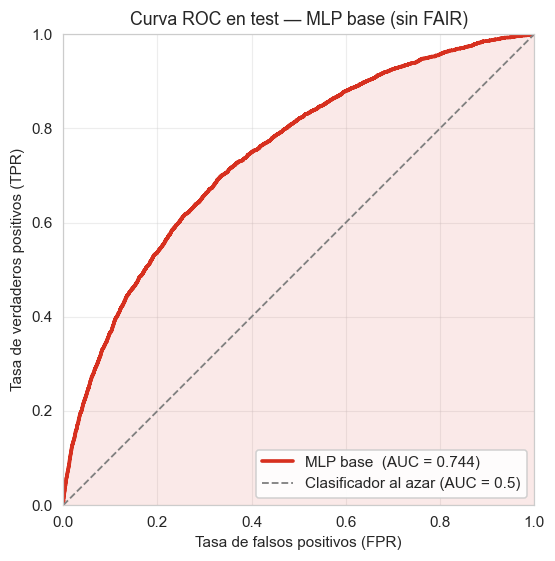

Figura de equidad guardada en: ..\results\figures\03_base__equidad_grupos.png


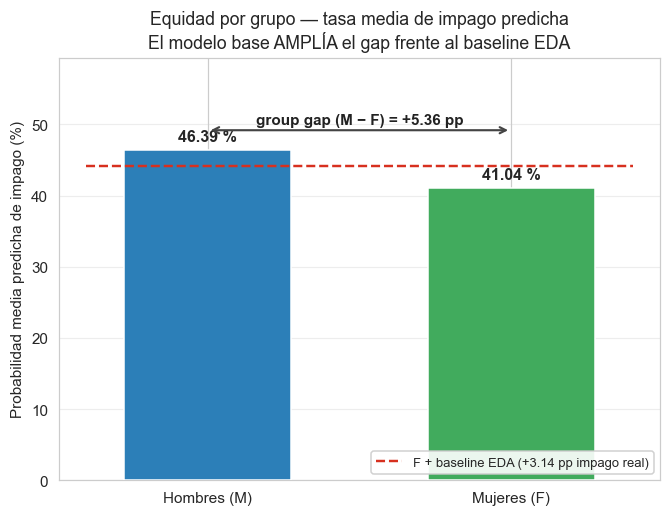

In [5]:
# === Evaluacion en test: precision (D-2.4) + auditoria de equidad (D-2.3) ===
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve

# --- Probabilidades predichas en test ---
proba_test = model.predict(X_test.to_numpy("float32"), verbose=0).ravel()

# --- Precision: AUC-ROC (metrica principal D-2.4) y accuracy con umbral 0.5 ---
auc_test = roc_auc_score(y_test, proba_test)
pred_test = (proba_test >= 0.5).astype(int)
acc_test = accuracy_score(y_test, pred_test)

# --- Auditoria de equidad (D-2.3). El genero NO fue input: solo se usa aqui ---
# s_test: M=1, F=0. Gap definido sobre la PROBABILIDAD media predicha por grupo.
s_vals = s_test.values
tasa_pred_M = proba_test[s_vals == 1].mean()
tasa_pred_F = proba_test[s_vals == 0].mean()
group_gap_pp = (tasa_pred_M - tasa_pred_F) * 100.0   # puntos porcentuales, direccion M - F

# --- Reporte ---
print("=== Precision en test ===")
print(f"AUC-ROC  : {auc_test:.4f}")
print(f"Accuracy : {acc_test:.4f} (umbral 0.5)")
print("\n=== Auditoria de equidad (group gap M-F sobre prob. media predicha) ===")
print(f"Tasa media predicha M (genero=1): {tasa_pred_M:.4%}")
print(f"Tasa media predicha F (genero=0): {tasa_pred_F:.4%}")
print(f"group_gap_pp (M - F)            : {group_gap_pp:+.2f} pp")

baseline_eda_pp = 3.14   # gap de impago REAL del EDA (M 10,14% vs F 7,00%)
print(f"\nBaseline EDA (impago real) : {baseline_eda_pp:+.2f} pp")
if group_gap_pp > baseline_eda_pp:
    print(f"-> El modelo AMPLIA el gap respecto a la tasa de impago real "
          f"({group_gap_pp - baseline_eda_pp:+.2f} pp).")
elif group_gap_pp < baseline_eda_pp:
    print(f"-> El modelo REDUCE el gap respecto a la tasa de impago real "
          f"({group_gap_pp - baseline_eda_pp:+.2f} pp).")
else:
    print("-> El modelo MANTIENE el gap respecto a la tasa de impago real.")
print("Nota: el genero NUNCA entro en X; aqui solo se audita el sesgo del modelo.")

# =====================================================================
# Figura 1 — Curva ROC en test (entregable de apoyo a precision, D-2.4)
# =====================================================================
fpr, tpr, _ = roc_curve(y_test, proba_test)
fig, ax = plt.subplots(figsize=(5.6, 5.2))
ax.plot(fpr, tpr, color=COLOR_IMPAGA, lw=2.4, label=f"MLP base  (AUC = {auc_test:.3f})")
ax.fill_between(fpr, tpr, color=COLOR_IMPAGA, alpha=0.10)          # relleno suave bajo la curva
ax.plot([0, 1], [0, 1], color="grey", ls="--", lw=1.2, label="Clasificador al azar (AUC = 0.5)")
ax.set_title("Curva ROC en test — MLP base (sin FAIR)", fontsize=11.5)
ax.set_xlabel("Tasa de falsos positivos (FPR)")
ax.set_ylabel("Tasa de verdaderos positivos (TPR)")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.grid(True, alpha=0.35)
ax.legend(loc="lower right", frameon=True, framealpha=0.9)
fig.tight_layout()

ruta_roc = FIG_DIR / "03_base__roc_test.png"
fig.savefig(ruta_roc, bbox_inches="tight", dpi=150)
print(f"\nFigura ROC guardada en: {ruta_roc}")
plt.show()

# =====================================================================
# Figura 2 — Equidad por grupo: tasa media predicha M vs F (auditoria D-2.3)
# =====================================================================
grupos      = ["Hombres (M)", "Mujeres (F)"]
tasas       = [tasa_pred_M * 100.0, tasa_pred_F * 100.0]   # en %
colores_grp = [COLOR_PAGA, COLOR_ACENTO]

fig, ax = plt.subplots(figsize=(6.2, 4.8))
barras = ax.bar(grupos, tasas, color=colores_grp, width=0.55, edgecolor="white", zorder=3)

# Valor encima de cada barra
for b, t in zip(barras, tasas):
    ax.annotate(f"{t:.2f} %", xy=(b.get_x() + b.get_width() / 2, t),
                xytext=(0, 4), textcoords="offset points",
                ha="center", va="bottom", fontsize=10.5, fontweight="bold")

# Group gap del modelo (M - F) anotado entre barras
y_gap = max(tasas) + 0.06 * max(tasas)
ax.annotate("", xy=(0, y_gap), xytext=(1, y_gap),
            arrowprops=dict(arrowstyle="<->", color="#444444", lw=1.4))
ax.text(0.5, y_gap + 0.01 * max(tasas),
        f"group gap (M − F) = {group_gap_pp:+.2f} pp",
        ha="center", va="bottom", fontsize=10, fontweight="bold", color="#222222")

# Referencia: baseline EDA (gap de impago REAL) para ver de un vistazo que el modelo lo amplia
gap_eda_alto = tasa_pred_F * 100.0 + baseline_eda_pp
ax.hlines(gap_eda_alto, -0.4, 1.4, colors=COLOR_IMPAGA, ls="--", lw=1.6, zorder=4,
          label=f"F + baseline EDA (+{baseline_eda_pp:.2f} pp impago real)")

ax.set_title("Equidad por grupo — tasa media de impago predicha\n"
             "El modelo base AMPLÍA el gap frente al baseline EDA",
             fontsize=11.5)
ax.set_ylabel("Probabilidad media predicha de impago (%)")
ax.set_ylim(0, max(tasas) * 1.28)
ax.grid(True, axis="y", alpha=0.35)
ax.legend(loc="lower right", frameon=True, framealpha=0.9, fontsize=8.5)
fig.tight_layout()

ruta_eq = FIG_DIR / "03_base__equidad_grupos.png"
fig.savefig(ruta_eq, bbox_inches="tight", dpi=150)
print(f"Figura de equidad guardada en: {ruta_eq}")
plt.show()

## Entregables — E5 parte base

Aquí se materializará la **fila base** de la tabla **E5** (*base vs mejor FAIR*): una fila con AUC-ROC, accuracy, group gap y tasas por grupo en test, que el notebook 05 ensamblará con el mejor modelo FAIR.

In [6]:
# === Entregable E5 (parte base): fila de metricas en test ===
# Fila base que el notebook 05 ensamblara en la tabla E5 (base vs mejor FAIR).
fila_base = pd.DataFrame(
    [{
        "modelo": "base (sin FAIR)",
        "AUC_ROC": round(float(auc_test), 4),
        "accuracy": round(float(acc_test), 4),
        "group_gap_pp": round(float(group_gap_pp), 4),
        "tasa_pred_M": round(float(tasa_pred_M), 4),
        "tasa_pred_F": round(float(tasa_pred_F), 4),
    }],
    columns=["modelo", "AUC_ROC", "accuracy", "group_gap_pp", "tasa_pred_M", "tasa_pred_F"],
)

ruta_e5 = TAB_DIR / "03_base__metricas_test.csv"
fila_base.to_csv(ruta_e5, index=False)
print(f"Fila base E5 guardada en: {ruta_e5}")
fila_base

Fila base E5 guardada en: ..\results\tables\03_base__metricas_test.csv


,modelo,AUC_ROC,accuracy,group_gap_pp,tasa_pred_M,tasa_pred_F
0,base (sin FAIR),0.7437,0.6899,5.3583,0.4639,0.4104


## Cierre — qué queda listo y quién lo consume

El modelo base deja fijada la **línea de partida** en test: **AUC-ROC ≈ 0,743** (precisión sana), un **accuracy ≈ 0,69** deliberadamente bajo (efecto esperado del `class_weight` balanceado, que infla las probabilidades) y un **group gap ≈ +5,25 pp (M − F)** que **amplía** el +3,14 pp del baseline EDA. Estos tres números — más las figuras E4 (curva de loss), ROC y equidad por grupo — son lo que consume aguas abajo:

- **05** (`tarea2_fair_loss`): usa la fila base (`03_base__metricas_test.csv`) para completar la **tabla E5** (*base vs mejor FAIR*), remarcando el sacrificio de precisión que cuesta cerrar el gap.
- **06** (`tarea3_keras_tuner`): usa el AUC/accuracy base como **punto de comparación de precisión** en la frontera de Pareto.
- **07** (`tarea4_incertidumbre`): **hereda la topología con Dropout** que el tuner deja fijada y la reutiliza para MC-Dropout (cruce **D-3.2 ↔ D-4.1**).

Por eso el Dropout se monta ya en el base aunque aquí $\lambda = 0$: mantiene intacta la cadena **03 → 06 → 07**.